In [19]:
import pandas as pd

df = pd.read_csv('../data/heart.csv')

In [20]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [22]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.select_dtypes(include='object').columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [25]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [26]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [27]:
for col in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    print(col)
    print(df[col].unique())
    print()

Sex
['M' 'F']

ChestPainType
['ATA' 'NAP' 'ASY' 'TA']

RestingECG
['Normal' 'ST' 'LVH']

ExerciseAngina
['N' 'Y']

ST_Slope
['Up' 'Flat' 'Down']



In [28]:
df = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

In [29]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [30]:
df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [31]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [32]:
print(X.shape)
print(y.shape)

(918, 15)
(918,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(734, 15)
(184, 15)
(734,)
(184,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8532608695652174


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_accuracy = rf.score(X_test, y_test)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.875


In [40]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
svm_accuracy = svm.score(X_test, y_test)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.875


In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
knn_accuracy = knn.score(X_test, y_test)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.8532608695652174


In [44]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [45]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

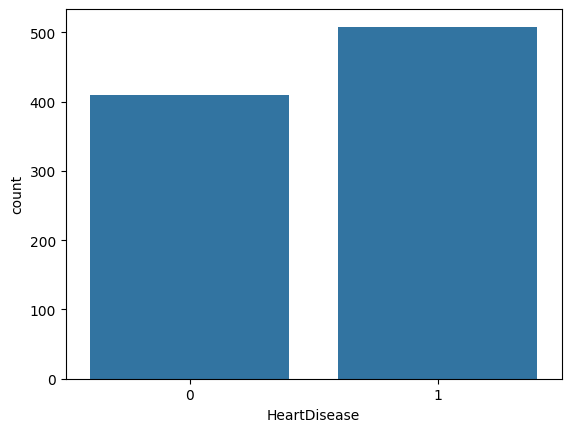

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='HeartDisease', data=df)
plt.show()

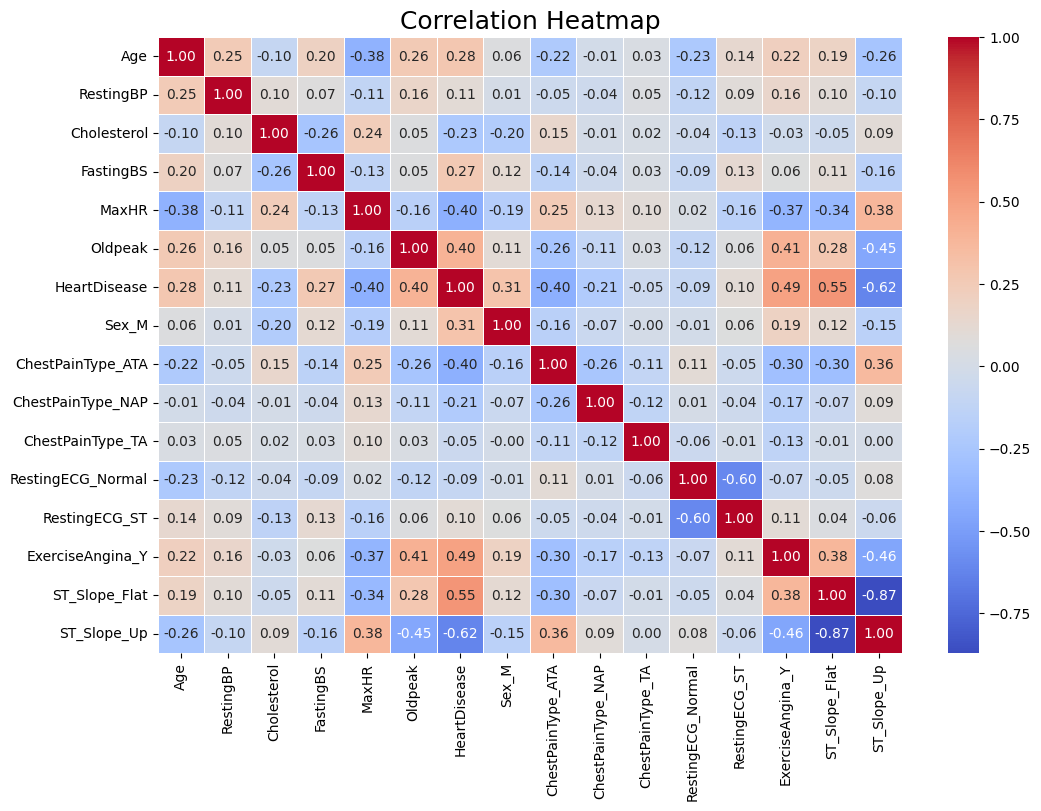

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=18)
plt.show()

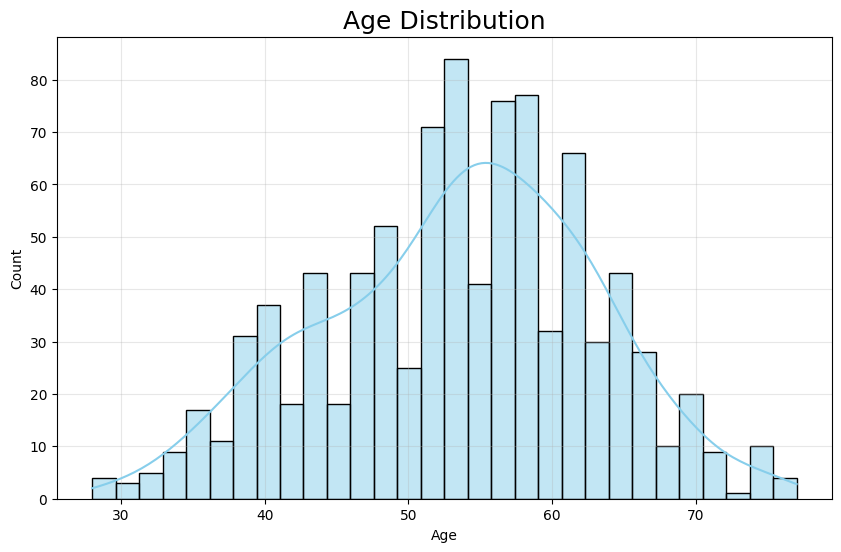

In [48]:
plt.figure(figsize=(10,6))

sns.histplot(df['Age'],
             bins=30,
             kde=True,
             color='skyblue')

plt.title('Age Distribution', fontsize=18)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(alpha=0.3)

plt.show()

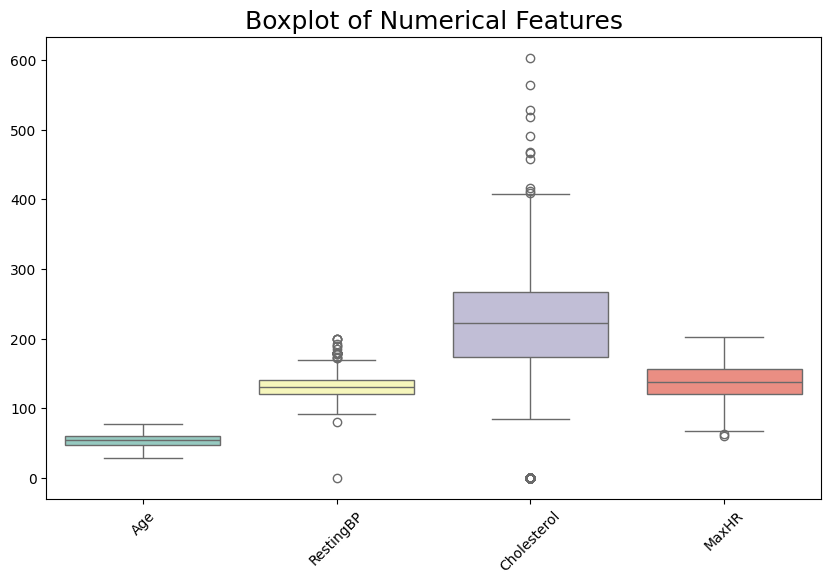

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR']],
            palette='Set3')

plt.title('Boxplot of Numerical Features', fontsize=18)
plt.xticks(rotation=45)

plt.show()

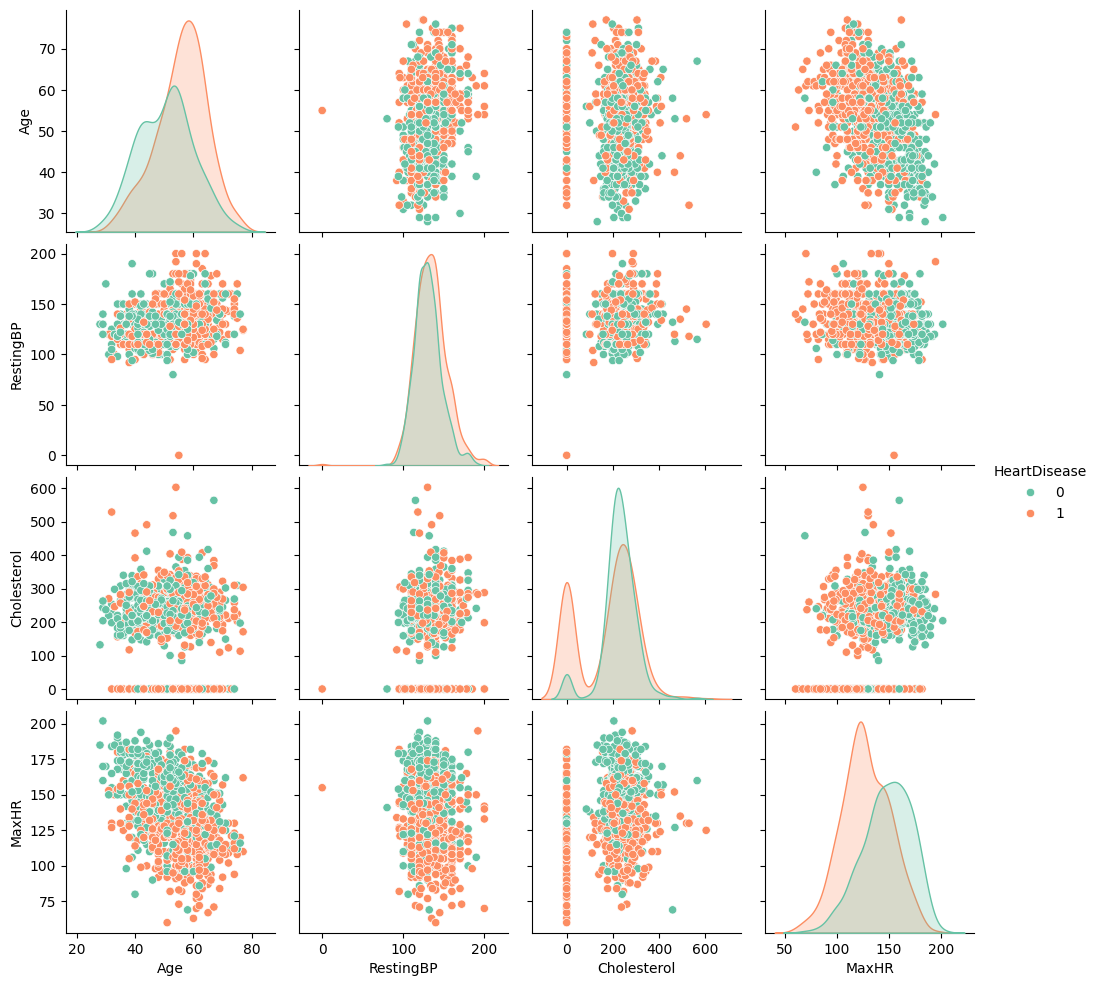

In [50]:
sns.pairplot(
    df[['Age','RestingBP','Cholesterol','MaxHR','HeartDisease']],
    hue='HeartDisease',
    palette='Set2'
)

plt.show()

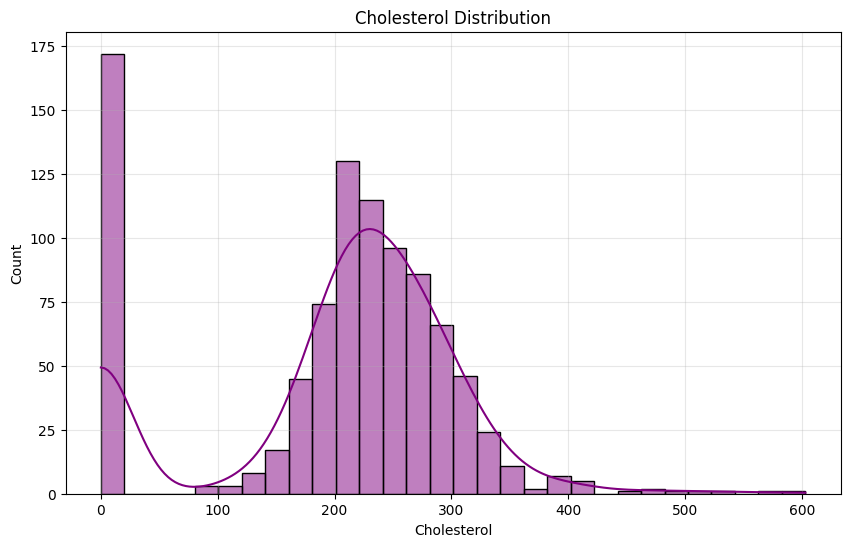

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Cholesterol'],
    kde=True,
    bins=30,
    color='purple'
)

plt.title('Cholesterol Distribution')
plt.grid(alpha=0.3)

plt.show()

C:\Users\DINESH\AppData\Local\Temp\ipykernel_19608\44031822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


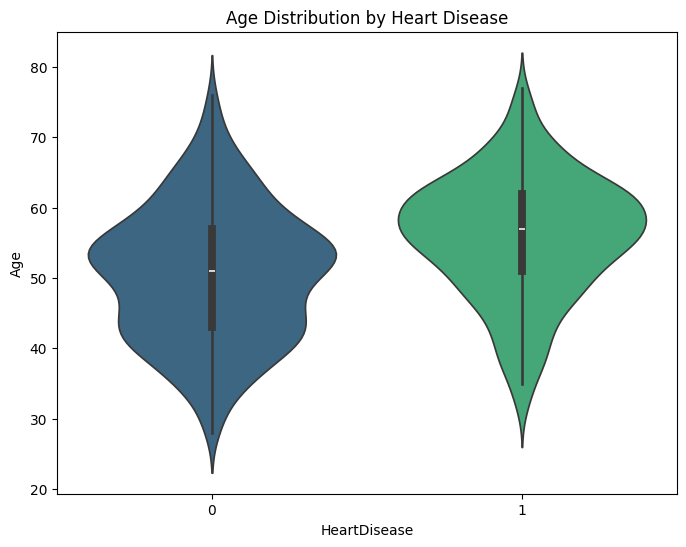

In [52]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x='HeartDisease',
    y='Age',
    data=df,
    palette='viridis'
)

plt.title('Age Distribution by Heart Disease')
plt.show()

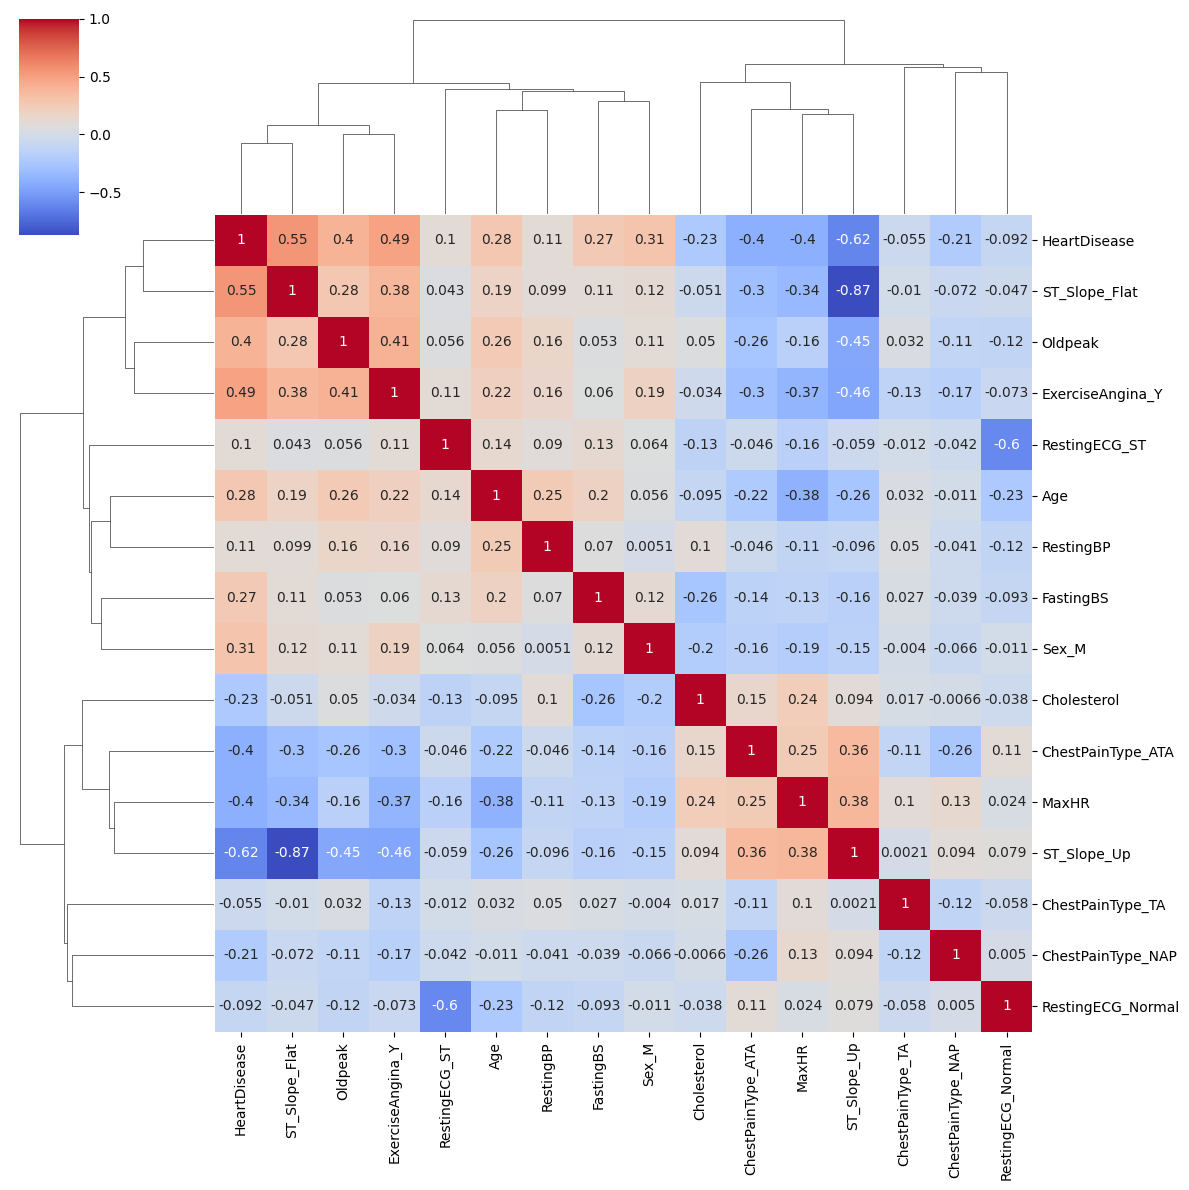

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    figsize=(12,12)
)

plt.show()

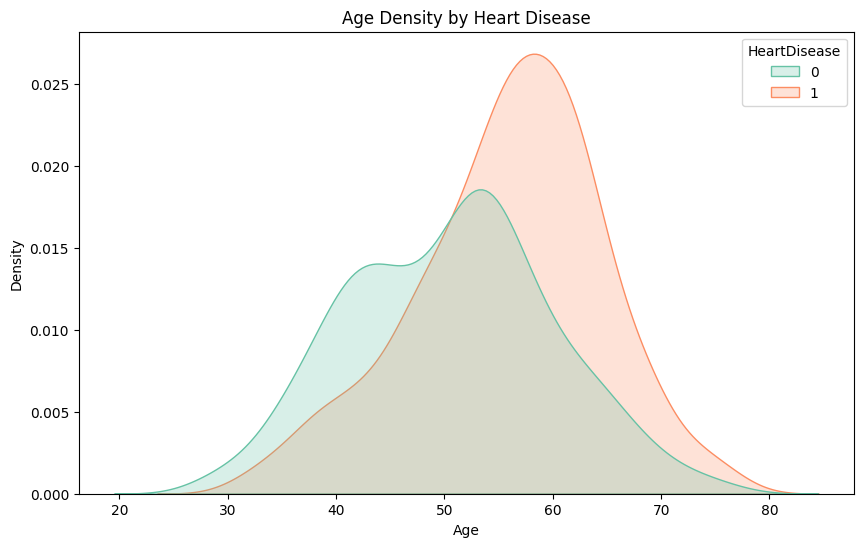

In [54]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='Age',
    hue='HeartDisease',
    fill=True,
    palette='Set2'
)

plt.title('Age Density by Heart Disease')

plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", model.score(X_test_scaled, y_test))

Accuracy: 0.8532608695652174


In [57]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

accuracy = svm_model.score(X_test_scaled, y_test)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.875


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Tuned RF Accuracy:", rf_model.score(X_test, y_test))

Tuned RF Accuracy: 0.8641304347826086


In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best Accuracy: 0.874643556052558


In [60]:
import joblib

joblib.dump(svm_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [61]:
!npm install -g localtunnel


added 22 packages in 9s

3 packages are looking for funding
  run `npm fund` for details


npm notice
npm notice New minor version of npm available! 11.9.0 -> 11.17.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.17.0
npm notice To update run: npm install -g npm@11.17.0
npm notice


In [65]:
!streamlit run app.py &>/dev/null &

OSError: Background processes not supported.

In [66]:
!npx localtunnel --port 8501

^C


In [70]:
import joblib

# after training
joblib.dump(svm_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [72]:
import pickle

pickle.dump(svm_model, open("heart_disease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [64]:
import joblib

# Save trained model
joblib.dump(svm_model, "heart_disease_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    results[name] = acc

print(results)

{'Logistic Regression': 0.8532608695652174, 'KNN': 0.8532608695652174, 'SVM': 0.875, 'Random Forest': 0.875}


In [ ]:
%%writefile app.py